# Cross-species splice-usage comparison via whole-genome alignment (multiz)

Like [splice_cross_species_divergence.ipynb](splice_cross_species_divergence.ipynb), but instead
of exon-level splice-site orthology, sites are matched across species with the **multiz100way
whole-genome alignment** (`*.maf.gz`).

## Pipeline
1. **Human sites** — all splice sites in the prediction data on human **chr8**.
2. **Alignment lift-over** — for each human site, read the aligned coordinate in each other
   species directly from the MAF (`hg38.chr8` ↔ mm10 / rn6 / oryCun2 / monDom5).
3. **Match to predictions** — snap each aligned coordinate to the nearest predicted site in that
   species (within `ALIGN_TOL` bp).
4. **Compare** — developmental **dynamics** (role: dynamic / flat) and **prediction accuracy**
   (Pearson r, RMSE) of the human site vs its aligned counterpart in each species.

## Setup

In [20]:
import os
import subprocess
import bisect
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import pearsonr

from alphagenome_pytorch.plotting.splicing import (
    classify_cluster_shape, SHAPE_ORDER,
    TISSUE_COLORS, TISSUE_ORDER, SPECIES_SCI,
)
plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

In [50]:
# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR   = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data"
USAGE_TMPL = os.path.join(DATA_DIR, "combined_usage_data_{species}.parquet")

MODEL      = "lora_32_human_mouse_rat_rabbit_opossum"
PRED_DIR   = os.path.join("/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai",
                          MODEL, "preds_all_intersect_protein_coding")

CHROMS     = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13"]   # one or more chromosomes, e.g. ["5", "8"]  

# species -> UCSC assembly name used in the multiz MAF
ASSEMBLY = {"mouse": "mm10", "rat": "rn6", "rabbit": "oryCun2", "opossum": "monDom5"}
OTHER_SPECIES = ["mouse", "rat", "rabbit", "opossum"]
# The MAF has rat as rn6, but the rat prediction data is on rn5, so rat aligned
# coordinates are lifted rn6 -> rn5 with a UCSC chain file (set RAT_CHAIN, or None to skip).
RAT_CHAIN = "/home/elek/sds/sd17d003/Anamaria/genomes/chains/rn6ToRn5.over.chain.gz"

FOCUS_TISSUE   = "Brain"
ALIGN_TOL      = 3      # bp: snap an aligned coordinate to the nearest predicted site
MIN_TIMEPOINTS = 6
AMP_DYNAMIC    = 0.50
AMP_FLAT       = 0.50
R_WELL_PRED    = 0.90
MAE_WELL_PRED  = 0.10

DYNAMIC_SHAPES = {"up_early", "up_late", "up_mid",
                  "down_early", "down_late", "down_mid", "up-down", "down-up"}
FLAT_SHAPES    = {"flat_low", "flat_mid_low", "flat_mid", "flat_mid_high", "flat_high"}

OUT_DIR = os.path.join(PRED_DIR, "human", "cross_species_alignment")
os.makedirs(OUT_DIR, exist_ok=True)

# per-chromosome MAF / reference prefix / lift-over cache
def maf_path(c):       return f"/home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr{c}.maf.gz"
def ref_prefix(c):     return f"hg38.chr{c}"
def liftover_cache(c): return os.path.join(OUT_DIR, f"liftover_chr{c}.parquet")
CHROM_TAG = "_".join(CHROMS)

def _pred_path(sp): return os.path.join(PRED_DIR, sp, f"usage_{sp}.parquet")
def _pred_npz(sp):  return os.path.join(PRED_DIR, sp, f"usage_{sp}.npz")

DATA_CONFIG = os.path.join(DATA_DIR, "data_config.json")

def ensure_pred_parquet(sp):
    """Build usage_{sp}.parquet from usage_{sp}.npz (+ data_config condition labels) if the
    parquet is missing but the npz exists. Returns 'parquet' / 'converted' / 'missing'."""
    if os.path.exists(_pred_path(sp)):
        return "parquet"
    if not os.path.exists(_pred_npz(sp)):
        return "missing"
    with open(DATA_CONFIG) as f:
        data_config = json.load(f)
    d = np.load(_pred_npz(sp))
    df = pd.DataFrame({"chr_pos": d["chr_pos"], "cond_ids": d["cond_ids"],
                       "SSE_pred": d["pred"], "SSE_true": d["true"]})
    df["Species"]    = sp
    df["Chromosome"] = df["chr_pos"].apply(lambda x: x.split(":")[0])
    df["Position"]   = df["chr_pos"].apply(lambda x: int(x.split(":")[1]))
    idx_to_name = {v: k for k, v in data_config[sp]["condition_labels"].items()}
    df["Condition_Name"] = df["cond_ids"].map(idx_to_name)
    raw = df["Condition_Name"].fillna("None_0").to_numpy()
    df["Tissue"]    = [s.split("_")[0] for s in raw]
    df["Timepoint"] = [int(s.split("_")[1]) for s in raw]
    df = df[["Species", "Chromosome", "Position", "SSE_true", "SSE_pred",
             "Condition_Name", "Tissue", "Timepoint"]]
    os.makedirs(os.path.dirname(_pred_path(sp)), exist_ok=True)
    df.to_parquet(_pred_path(sp), index=False)
    return "converted"

for c in CHROMS:
    print(f"chr{c} MAF:", maf_path(c), "| exists:", os.path.exists(maf_path(c)))
for sp in ["human"] + OTHER_SPECIES:
    status = ensure_pred_parquet(sp)
    tag = {"parquet": "OK  ", "converted": "CONV", "missing": "MISS"}[status]
    note = " (npz -> parquet)" if status == "converted" else ""
    print(f"{tag}  {sp} predictions{note}")

chr1 MAF: /home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr1.maf.gz | exists: True
chr2 MAF: /home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr2.maf.gz | exists: True
chr3 MAF: /home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr3.maf.gz | exists: True
chr4 MAF: /home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr4.maf.gz | exists: True
chr5 MAF: /home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr5.maf.gz | exists: True
chr6 MAF: /home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr6.maf.gz | exists: True
chr7 MAF: /home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr7.maf.gz | exists: True
chr8 MAF: /home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr8.maf.gz | exists: True
chr9 MAF: /home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr9.maf.gz | exists: True
chr10 MAF: /home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr10.maf.gz | exists: True
chr11 MAF: /home/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr11.maf.gz | exists: 

## Helpers

In [45]:
from alphagenome_pytorch import xspecies as sx

# Shared helpers live in alphagenome_pytorch.xspecies; thin wrappers bind this
# notebook's config so the rest of the notebook keeps the same names/signatures
# (and the same helpers are reused by splice_cross_species_usage.ipynb).
TPS = sx.TPS

def load_focus_usage(sp, tissue, positions=None):
    return sx.load_focus_usage(USAGE_TMPL, sp, tissue, positions)

def trajectory_stats(df):
    return sx.trajectory_stats(df)

def classify_traj(vec):
    return sx.classify_traj(vec, MIN_TIMEPOINTS)

def is_dynamic_shape(s):
    return sx.is_dynamic_shape(s)

def role(shape, amplitude):
    return sx.role(shape, amplitude, DYNAMIC_SHAPES, FLAT_SHAPES, AMP_DYNAMIC, AMP_FLAT)

def xcorr(a, b):
    return sx.xcorr(a, b)

def load_predictions(sp, tissue, positions=None):
    p = sx.load_predictions(PRED_DIR, DATA_DIR, SPECIES_SCI, sp, tissue, positions)
    return sx.attach_strand(p, USAGE_TMPL, sp)   # add Strand -> site ids carry strand

def pred_site_metrics(pred_df):
    return sx.pred_site_metrics(pred_df)

def is_well_predicted(pred_r, pred_rmse, true_dynamic):
    return sx.is_well_predicted(pred_r, pred_rmse, true_dynamic, R_WELL_PRED, MAE_WELL_PRED)

## 1 — Human sites (from the prediction data)

In [ ]:
# Load all predictions for selected chromosome
pred_human = load_predictions("human", FOCUS_TISSUE)
if pred_human is None:
    raise FileNotFoundError("No human predictions found")
pred_human = pred_human[pred_human["Chromosome"].isin(CHROMS)].copy()
pred_human = sx.add_site_col(pred_human)          # site id = chrom:pos:strand

# Calculate trajectory stats
hu_stats, hu_wide = trajectory_stats(
    load_focus_usage("human", FOCUS_TISSUE, positions=pred_human["Position"].unique()))
hu_stats = hu_stats[hu_stats["Chromosome"].isin(CHROMS)].copy()

# Merge usage stats with predictions
human = hu_stats.merge(pred_site_metrics(pred_human).reset_index(), on="site", how="inner")

# Subset for minimum number of timepoints
human = human[human["n_obs"] >= MIN_TIMEPOINTS].copy()

# Classify trajectory for each site
human["shape"] = [classify_traj(hu_wide.loc[s].to_numpy()) for s in human["site"]]
human["role"]  = [role(sh, a) for sh, a in zip(human["shape"], human["amplitude"])]

print(f"Human chr{CHROM_TAG} sites with usage + predictions: {len(human):,}")
print("roles:", human["role"].value_counts(dropna=False).to_dict())
human.sort_values("amplitude", ascending=False).head()

## 2 — Lift over to other species via the multiz alignment

Stream the MAF once; for each human site read the aligned coordinate in each target assembly.
Cached to parquet so it's only parsed once. (Streaming the 3.5 GB file takes a few minutes.)

In [24]:
# The multiz MAF whole-genome-alignment lift-over lives in the shared module.
maf_liftover = sx.maf_liftover

In [ ]:
# -- Load cached lift-over or parse MAF, per chromosome --
# Each chromosome has its own cache of raw assembly-native coordinates (tissue-independent).
def all_ref_positions(c):
    """All human chr{c} predicted-site positions, independent of tissue."""
    ppath = _pred_path("human")
    if os.path.exists(ppath):
        s = pd.read_parquet(ppath, columns=["Chromosome", "Position"]).drop_duplicates()
        s = s[s["Chromosome"].astype(str) == c]
        return sorted(s["Position"].astype(int).unique().tolist())
    d = np.load(_pred_npz("human"))
    cp = np.asarray(d["chr_pos"]).astype(str)
    ch = np.array([x.split(":")[0] for x in cp]); po = np.array([int(x.split(":")[1]) for x in cp])
    return sorted(np.unique(po[ch == c]).tolist())

asm2sp = {a: s for s, a in ASSEMBLY.items()}
parts, n_positions = [], 0
for c in CHROMS:
    positions = all_ref_positions(c)
    n_positions += len(positions)
    cache = liftover_cache(c)
    if os.path.exists(cache):
        part = pd.read_parquet(cache)
        print(f"chr{c}: loaded cache ({len(part):,} rows) for {len(positions):,} predicted sites")
    else:
        print(f"chr{c}: parsing MAF for {len(positions):,} human sites ...")
        res = maf_liftover(maf_path(c), ref_prefix(c), positions, set(ASSEMBLY.values()))
        rows = []
        for hpos, d in res.items():
            for asm, (tchrom, tpos, tstrand) in d.items():
                rows.append(dict(human_site=f"{c}:{hpos}", species=asm2sp[asm],
                                 assembly=asm, aln_chrom=str(tchrom), aln_pos=int(tpos),
                                 aln_strand=tstrand))
        part = pd.DataFrame(rows)
        part.to_parquet(cache, index=False)
        print(f"chr{c}: saved lift-over -> {cache}")
    parts.append(part)
    
lift_df = pd.concat(parts, ignore_index=True)

# ── Rat: lift MAF coordinates rn6 -> rn5 (the assembly of the rat prediction data) ──
# The caches store raw assembly-native (rn6) coordinates; the chain conversion is applied
# here on load so it stays reproducible if the chain changes.
if RAT_CHAIN and os.path.exists(RAT_CHAIN) and (lift_df["species"] == "rat").any():
    from pyliftover import LiftOver
    _lo = LiftOver(RAT_CHAIN)
    mask = lift_df["species"] == "rat"
    n_before = int(mask.sum())
    new_chrom, new_pos = [], []
    for _, r in lift_df[mask].iterrows():
        conv = _lo.convert_coordinate("chr" + str(r["aln_chrom"]), int(r["aln_pos"]))
        if conv:
            cc, pos = conv[0][0], conv[0][1]
            new_chrom.append(cc.removeprefix("chr")); new_pos.append(int(pos))
        else:
            new_chrom.append(None); new_pos.append(np.nan)
    lift_df.loc[mask, "aln_chrom"] = new_chrom
    lift_df.loc[mask, "aln_pos"]   = new_pos
    lift_df.loc[mask, "assembly"]  = "rn6->rn5"
    lift_df = lift_df[lift_df["aln_pos"].notna()].copy()
    lift_df["aln_pos"] = lift_df["aln_pos"].astype(int)
    print(f"rat rn6->rn5 chain lift: {int((lift_df['species']=='rat').sum()):,}/{n_before:,} lifted")
elif (lift_df["species"] == "rat").any() and not (RAT_CHAIN and os.path.exists(RAT_CHAIN)):
    print("rat: RAT_CHAIN not available — rat coordinates left as rn6 (may not match rn5 predictions)")

# canonicalise human_site to chrom:pos:strand (upgrades legacy strand-less caches)
h_strand = sx.strand_series(USAGE_TMPL, "human")
lift_df["human_site"] = lift_df["human_site"].map(lambda s: sx.ensure_site_strand(s, h_strand))

print(f"Aligned mappings: {len(lift_df):,}")
print("per species:", lift_df["species"].value_counts().to_dict())
print(f"human chr{CHROM_TAG} sites with >=1 alignment: {lift_df['human_site'].nunique():,} / {n_positions:,}")
lift_df.head()

## 3 — Match aligned coordinates to predicted sites & compare

For each species, snap the aligned coordinate to the nearest predicted site (≤ `ALIGN_TOL` bp),
then read that site's trajectory and prediction accuracy.

In [46]:
def _nearest(sorted_pos, pos, tol):
    if len(sorted_pos) == 0: return None
    j = bisect.bisect_left(sorted_pos, pos)
    cand = [sorted_pos[k] for k in (j - 1, j) if 0 <= k < len(sorted_pos)]
    if not cand: return None
    best = min(cand, key=lambda x: abs(x - pos))
    return int(best) if abs(best - pos) <= tol else None

records = {s: {} for s in human["site"]}          # human_site -> {species: dict}
other_wide, other_pred_wide = {}, {}

hu_by_site = human.set_index("site")

for sp in OTHER_SPECIES:
    # lift_df covers all chr8 sites; restrict to the focus-tissue analysis set
    sub = lift_df[(lift_df["species"] == sp) & (lift_df["human_site"].isin(set(human["site"])))]
    if sub.empty:
        print(f"{sp}: no alignments"); continue
    # candidate aligned positions per chrom (+/- ALIGN_TOL window so nearby sites load)
    pos_expand = sorted({int(p) + d for p in sub["aln_pos"] for d in range(-ALIGN_TOL, ALIGN_TOL + 1)})

    st_sp, wide_sp = trajectory_stats(load_focus_usage(sp, FOCUS_TISSUE, positions=pos_expand))
    st_sp = st_sp.set_index("site")
    pred_sp = load_predictions(sp, FOCUS_TISSUE, positions=pos_expand)
    if pred_sp is None:
        pm_sp = pw_sp = None
        print(f"{sp}: predictions MISSING")
    else:
        pm_sp = pred_site_metrics(pred_sp)
        pred_sp = sx.add_site_col(pred_sp)          # site id = chrom:pos:strand
        pw_sp = (pred_sp.groupby(["site", "Timepoint"])["pred"].mean()
                        .unstack("Timepoint").reindex(columns=TPS))

    # positions to snap to: predicted sites (so pred metrics exist), else usage sites
    snap_src = pred_sp if (pm_sp is not None and len(pred_sp)) else st_sp.reset_index()
    snap_src = snap_src.copy(); snap_src["Chromosome"] = snap_src["Chromosome"].astype(str)
    if "site" not in snap_src.columns:
        snap_src = sx.add_site_col(snap_src)
    pos_by_chrom = {c: np.sort(np.unique(d["Position"].astype(int).values))
                    for c, d in snap_src.groupby(snap_src["Chromosome"].astype(str))}
    site_by_cp = {(str(c), int(pp)): s for c, pp, s in
                  zip(snap_src["Chromosome"], snap_src["Position"], snap_src["site"])}

    ow  = pd.DataFrame(index=human["site"], columns=TPS, dtype=float)
    opw = pd.DataFrame(index=human["site"], columns=TPS, dtype=float)
    n_hit = n_snap = 0
    for _, r in sub.iterrows():
        hsite = r["human_site"]; chrom = str(r["aln_chrom"]); apos = int(r["aln_pos"])
        snapped = _nearest(pos_by_chrom.get(chrom, np.array([])), apos, ALIGN_TOL)
        if snapped is None: continue
        ssite = site_by_cp.get((chrom, snapped))     # full chrom:pos:strand id
        if ssite is None or ssite not in st_sp.index: continue
        n_hit += 1; n_snap += (snapped != apos)
        row = st_sp.loc[ssite]; traj_o = wide_sp.loc[ssite].to_numpy()
        ow.loc[hsite] = traj_o
        hu_traj = hu_wide.loc[hsite].to_numpy()
        rec = dict(aln_site=ssite, aln_dist=abs(snapped - apos),
                   n_obs=int(row["n_obs"]), amplitude=float(row["amplitude"]),
                   shape=classify_traj(traj_o), corr=xcorr(hu_traj, traj_o),
                   pred_r=np.nan, pred_rmse=np.nan)
        rec["role"] = role(rec["shape"], rec["amplitude"])
        if pm_sp is not None and ssite in pm_sp.index:
            rec["pred_r"] = float(pm_sp.loc[ssite, "pred_r"])
            rec["pred_rmse"] = float(pm_sp.loc[ssite, "pred_rmse"])
            if pw_sp is not None and ssite in pw_sp.index:
                opw.loc[hsite] = pw_sp.loc[ssite].to_numpy()
        records[hsite][sp] = rec
    other_wide[sp] = ow; other_pred_wide[sp] = opw
    print(f"{sp}: {n_hit:,} aligned sites matched to a predicted usage site "
          f"({n_snap:,} snapped <= {ALIGN_TOL}bp)")

mouse: 16,812 aligned sites matched to a predicted usage site (143 snapped <= 3bp)
rat: 14,057 aligned sites matched to a predicted usage site (153 snapped <= 3bp)
rabbit: 12,141 aligned sites matched to a predicted usage site (123 snapped <= 3bp)
opossum: 13,289 aligned sites matched to a predicted usage site (164 snapped <= 3bp)


In [47]:
# ── Comparison table: one row per (human site, species) ───────────────────────
rows = []
for hsite in human["site"]:
    h = hu_by_site.loc[hsite]
    #if hsite == "8:130160784":
    #    print("DEBUG:", hsite, h.to_dict())
    for sp in OTHER_SPECIES:
        rec = records[hsite].get(sp)
        if not rec or rec["n_obs"] < MIN_TIMEPOINTS:
            #if hsite == "8:130160784":
            #    print(f"DEBUG: skipping {hsite} {sp}: rec={rec}")
            continue
        rows.append(dict(
            human_site=hsite, species=sp, aln_site=rec["aln_site"], aln_dist=rec["aln_dist"],
            human_role=h["role"], human_shape=h["shape"], human_amp=round(float(h["amplitude"]), 3),
            human_pred_r=round(float(h["pred_r"]), 3), human_pred_rmse=round(float(h["pred_rmse"]), 3),
            other_role=rec["role"], other_shape=rec["shape"], other_amp=round(rec["amplitude"], 3),
            other_pred_r=round(rec["pred_r"], 3) if np.isfinite(rec["pred_r"]) else np.nan,
            other_pred_rmse=round(rec["pred_rmse"], 3) if np.isfinite(rec["pred_rmse"]) else np.nan,
            xspecies_corr=round(rec["corr"], 3) if np.isfinite(rec["corr"]) else np.nan,
            same_role=(h["role"] is not None and h["role"] == rec["role"]),
            divergent=(h["role"] is not None and rec["role"] is not None and h["role"] != rec["role"]),
        ))
comp = pd.DataFrame(rows)
out_csv = os.path.join(OUT_DIR, f"alignment_comparison_chr{CHROM_TAG}_{FOCUS_TISSUE.lower()}.csv")
comp.to_csv(out_csv, index=False)
print(f"{len(comp):,} (human site, species) aligned pairs")
print(f"Saved -> {out_csv}")
comp.head(20)

52,135 (human site, species) aligned pairs
Saved -> /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/preds_all_intersect_protein_coding/human/cross_species_alignment/alignment_comparison_chr1_2_3_4_5_6_7_8_9_10_11_12_13_brain.csv


,human_site,species,aln_site,aln_dist,human_role,human_shape,human_amp,human_pred_r,human_pred_rmse,other_role,other_shape,other_amp,other_pred_r,other_pred_rmse,xspecies_corr,same_role,divergent
0,1:1535506:-,mouse,4:155739845:+,0,None,up_early,0.423,0.795,0.118,None,up_late,0.348,0.507,0.221,0.136,False,False
1,1:1535588:-,mouse,4:155739771:+,0,None,up_early,0.411,0.845,0.090,None,up_mid,0.275,0.302,0.265,-0.628,False,False
2,1:1535796:-,mouse,4:155739563:+,0,None,up_early,0.244,0.896,0.115,None,up_early,0.477,0.549,0.146,0.639,False,False
3,1:1539683:-,mouse,4:155735503:+,0,None,up_early,0.274,0.810,0.107,dynamic,up_early,0.802,-0.023,0.304,0.911,False,False
4,1:1539789:-,mouse,4:155735397:+,0,None,up_early,0.455,0.844,0.104,None,up_late,0.376,0.464,0.179,0.432,False,False
5,1:1540289:-,mouse,4:155735145:+,0,None,up_early,0.479,0.906,0.138,None,up_mid,0.490,0.380,0.358,0.158,False,False
6,1:2336849:-,rat,5:175986249:+,0,None,up_early,0.588,0.746,0.273,None,down_late,0.183,-0.384,0.563,NaN,False,False
7,1:2357431:-,rat,5:175968906:+,0,None,up-down,0.399,0.177,0.204,flat,flat_high,0.091,0.354,0.400,-0.354,False,False
8,1:2358714:-,rat,5:175968132:+,0,flat,flat_high,0.142,0.064,0.221,None,up-down,0.284,0.143,0.183,-0.463,False,False
9,1:2372480:-,rat,5:175960446:+,0,None,up_late,0.409,0.085,0.170,flat,flat_high,0.182,-0.386,0.268,-0.672,False,False


## 4 — Summary: dynamics concordance & prediction accuracy across species

,n_pairs,median_aln_dist,median_xspecies_corr,frac_same_role,frac_divergent,human_median_pred_r,other_median_pred_r,human_median_rmse,other_median_rmse
species,,,,,,,,,
mouse,15256,0.0,-0.057,0.370,0.009,0.503,0.273,0.106,0.111
opossum,12231,0.0,0.036,0.444,0.010,0.513,0.115,0.103,0.105
rabbit,11405,0.0,0.009,0.411,0.007,0.496,0.100,0.105,0.106
rat,13243,0.0,-0.022,0.398,0.010,0.514,0.236,0.105,0.102


Role concordance (rows = human, cols = other species):


other_role,dynamic,flat,none
human_role,,,
dynamic,254,220,375
flat,237,20787,7125
none,846,11898,10393


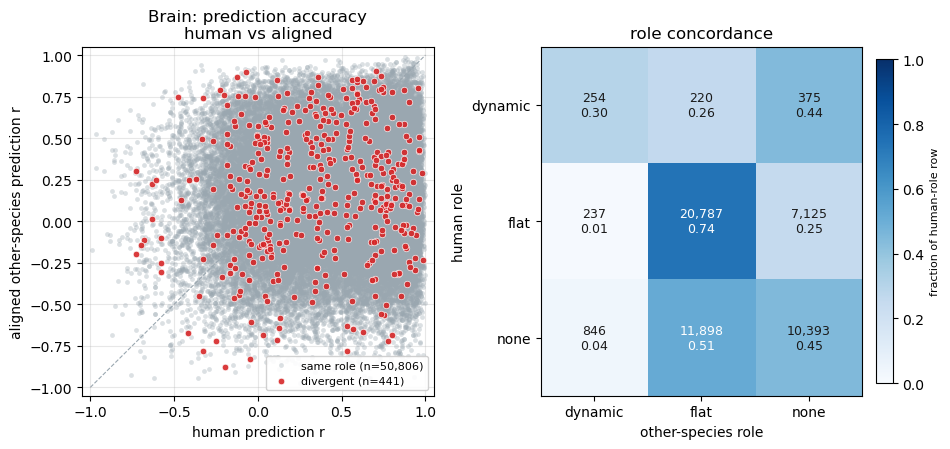

In [48]:
if len(comp):
    g = comp.groupby("species")
    summary = pd.DataFrame({
        "n_pairs":          g.size(),
        "median_aln_dist":  g["aln_dist"].median(),
        "median_xspecies_corr": g["xspecies_corr"].median(),
        "frac_same_role":   g["same_role"].mean(),
        "frac_divergent":   g["divergent"].mean(),
        "human_median_pred_r":  g["human_pred_r"].median(),
        "other_median_pred_r":  g["other_pred_r"].median(),
        "human_median_rmse":    g["human_pred_rmse"].median(),
        "other_median_rmse":    g["other_pred_rmse"].median(),
    }).round(3)
    display(summary)

    # dynamics concordance: human role vs other role
    ct = pd.crosstab(comp["human_role"].fillna("none"), comp["other_role"].fillna("none"))
    role_order = [r for r in ["dynamic", "flat", "none"] if r in ct.index or r in ct.columns]
    ct = ct.reindex(index=role_order, columns=role_order, fill_value=0)
    print("Role concordance (rows = human, cols = other species):")
    display(ct)

    CONCORDANT, DIVERGENT = "#9aa7b0", "#d62728"   # neutral vs reserved "serious" status
    fig, (ax, axh) = plt.subplots(1, 2, figsize=(9.6, 4.6),
                                  gridspec_kw={"width_ratios": [1, 1]})

    # ── accuracy scatter: human vs aligned other-species prediction r ──
    d = comp.dropna(subset=["human_pred_r", "other_pred_r"])
    dc, dd = d[~d["divergent"]], d[d["divergent"]]
    ax.plot([-1, 1], [-1, 1], "--", color="#9aa7b0", lw=0.8, zorder=1)
    ax.scatter(dc["human_pred_r"], dc["other_pred_r"], s=12, alpha=0.35,
               c=CONCORDANT, linewidths=0, zorder=2, label=f"same role (n={len(dc):,})")
    ax.scatter(dd["human_pred_r"], dd["other_pred_r"], s=22, alpha=0.9,     # divergent ON TOP
               c=DIVERGENT, edgecolors="white", linewidths=0.5, zorder=3,
               label=f"divergent (n={len(dd):,})")
    ax.set_xlabel("human prediction r"); ax.set_ylabel("aligned other-species prediction r")
    ax.set_title(f"{FOCUS_TISSUE}: prediction accuracy\nhuman vs aligned")
    ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
    ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=8, framealpha=0.9)

    # ── role-concordance heatmap (color = row-normalised fraction, text = counts) ──
    frac = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0)
    im = axh.imshow(frac.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
    axh.set_xticks(range(len(ct.columns))); axh.set_xticklabels(ct.columns)
    axh.set_yticks(range(len(ct.index)));   axh.set_yticklabels(ct.index)
    axh.set_xlabel("other-species role"); axh.set_ylabel("human role")
    axh.set_title("role concordance")
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            f = frac.iloc[i, j]
            txt = f"{int(ct.iloc[i, j]):,}\n{f:.2f}" if np.isfinite(f) else f"{int(ct.iloc[i, j]):,}"
            axh.text(j, i, txt, ha="center", va="center",
                     fontsize=9, color="white" if (np.isfinite(f) and f > 0.5) else "#1a1a1a")
    cbar = fig.colorbar(im, ax=axh, fraction=0.046, pad=0.04)
    cbar.set_label("fraction of human-role row", fontsize=8)

    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"accuracy_and_role_concordance_chr{CHROM_TAG}.png"),
                dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No aligned pairs — check ALIGN_TOL / assembly names / predictions.")

## 5 — Example trajectories

### 5a — Correctly predicted divergent trajectories
Well-predicted human sites whose aligned counterpart has a **different role** (dynamic ↔ flat).
True (solid) vs predicted (dashed) usage, one panel per species.

In [ ]:
def _load_all_tissues(sp, positions):
    posset = {int(x) for x in positions}
    ppath = _pred_path(sp)
    if os.path.exists(ppath):
        try:
            df = pd.read_parquet(ppath, filters=[("Position", "in", list(posset))])
        except Exception:
            df = pd.read_parquet(ppath); df = df[df["Position"].isin(posset)]
        df = df.rename(columns={"true": "SSE_true", "pred": "SSE_pred"})
        if "Species" not in df.columns: df["Species"] = sp
        df["Chromosome"] = df["Chromosome"].astype(str)
        return df
    return None

# well-predicted human + divergent, correctly predicted in the aligned species
cand = comp[(comp["human_pred_r"] >= R_WELL_PRED)
            & (comp["divergent"])
            & (comp["other_pred_rmse"] <= MAE_WELL_PRED)]
cand = cand.sort_values("human_pred_r", ascending=False)
print(f"{cand['human_site'].nunique():,} human sites divergent & well-predicted in an aligned species")

display(cand)

5 human sites divergent & well-predicted in an aligned species


,human_site,species,aln_site,aln_dist,human_role,human_shape,human_amp,human_pred_r,human_pred_rmse,other_role,other_shape,other_amp,other_pred_r,other_pred_rmse,xspecies_corr,same_role,divergent
9988,1:222991519:+,rabbit,16:50061028:-,0,dynamic,up_early,0.895,0.985,0.273,flat,flat_high,0.120,-0.233,0.089,-0.764,False,True
39478,6:117693041:+,mouse,10:52429192:+,0,dynamic,up_early,0.714,0.964,0.253,flat,flat_high,0.102,0.420,0.091,0.180,False,True
39481,6:117693041:+,opossum,2:386045670:+,0,dynamic,up_early,0.714,0.964,0.253,flat,flat_high,0.088,0.131,0.077,-0.737,False,True
44895,7:152229922:-,rabbit,13:13582617:-,0,dynamic,up-down,0.601,0.955,0.252,flat,flat_high,0.039,0.073,0.071,0.999,False,True
15127,2:25771439:-,rat,6:37692322:+,0,dynamic,down_early,0.709,0.927,0.274,flat,flat_high,0.122,0.300,0.074,-0.652,False,True
14077,10:116692466:-,opossum,1:93370377:+,0,dynamic,up_early,0.740,0.904,0.190,flat,flat_high,0.060,-0.246,0.076,0.049,False,True
14075,10:116692466:-,rat,1:287334555:-,0,dynamic,up_early,0.740,0.904,0.190,flat,flat_high,0.058,0.165,0.075,0.154,False,True
14076,10:116692466:-,rabbit,18:64247085:-,0,dynamic,up_early,0.740,0.904,0.190,flat,flat_high,0.123,0.488,0.065,-0.184,False,True


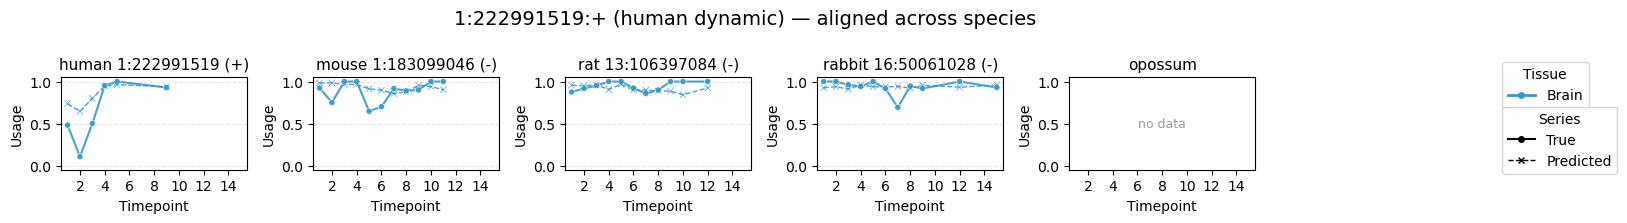

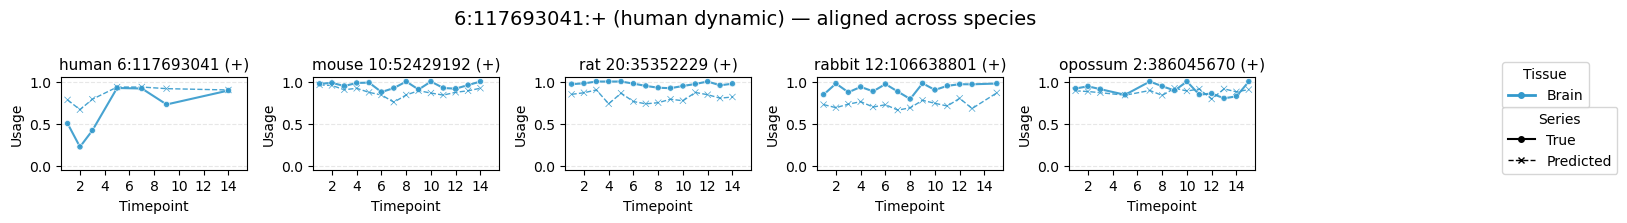

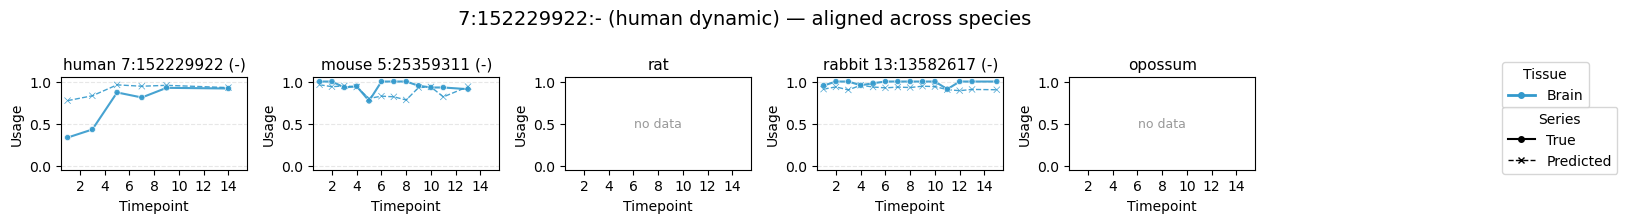

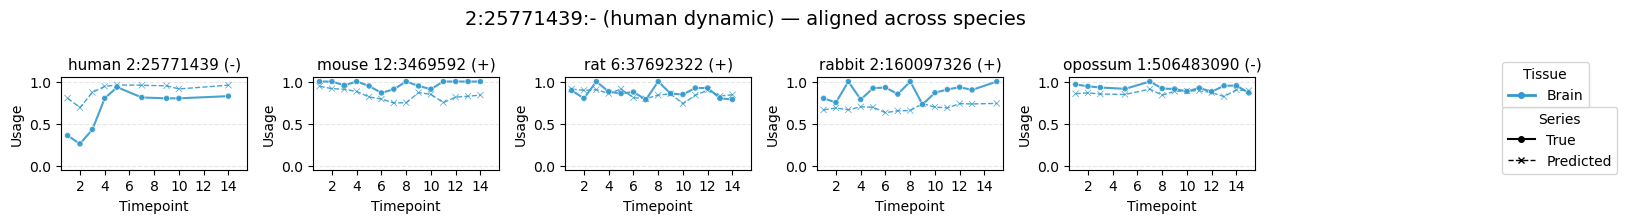

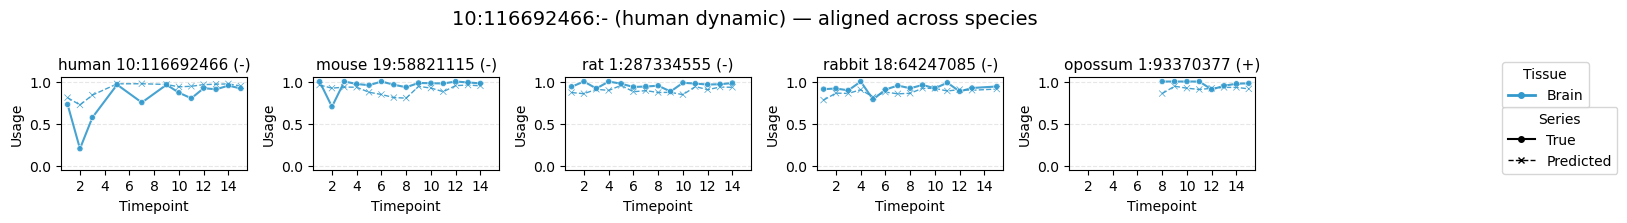

In [63]:
#from alphagenome_pytorch.plotting.splicing import plot_splice_site_predictions
N_PLOT = 10

top = cand.drop_duplicates("human_site").head(N_PLOT)
for _, r in top.iterrows():
    hsite = r["human_site"]
    hchrom = sx.parse_site(hsite)[0]
    frames, coords = [], []
    hf = _load_all_tissues("human", [sx.parse_site(hsite)[1]])
    if hf is not None: frames.append(hf)
    coords.append(f"human {hsite}")                     # human column always present
    for sp in OTHER_SPECIES:                            # one fixed column per species
        rec = records[hsite].get(sp)
        added = False
        if rec:
            ap = sx.parse_site(rec["aln_site"])[1]
            f = _load_all_tissues(sp, [ap])
            if f is not None and not f.empty:
                frames.append(f); coords.append(f"{sp} {rec['aln_site']}"); added = True
        if not added:
            coords.append(f"{sp} {hchrom}:0")           # placeholder -> empty panel
    fig = plot_splice_site_predictions(
        pd.concat(frames, ignore_index=True), site_coords=coords,
        true_col="SSE_true", pred_col="SSE_pred",
        tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER,
        tissue_subset=[FOCUS_TISSUE], n_cols=len(coords), split_by_tissue=False, show_missing=True,
        title=f"{hsite} (human {r['human_role']}) — aligned across species",
    )
    if fig is not None:
        for ax in fig.axes: ax.set_ylim(-0.05, 1.05)
        fig.savefig(os.path.join(OUT_DIR, f"aligned_{hsite.replace(':', '_')}.png"),
                    dpi=200, bbox_inches="tight")
        plt.show()

### 5b — Incorrectly predicted divergent trajectories

The same divergent (dynamic ↔ flat) sites, but where the model gets the dynamics **wrong** —
human poorly predicted (`human_pred_r < R_WELL_PRED`) and/or the aligned species poorly
predicted (`other_pred_r > R_WELL_PRED`). Worst-predicted shown first, as a contrast to 
the well-predicted examples above.

56 human sites divergent & mispredicted in an aligned species


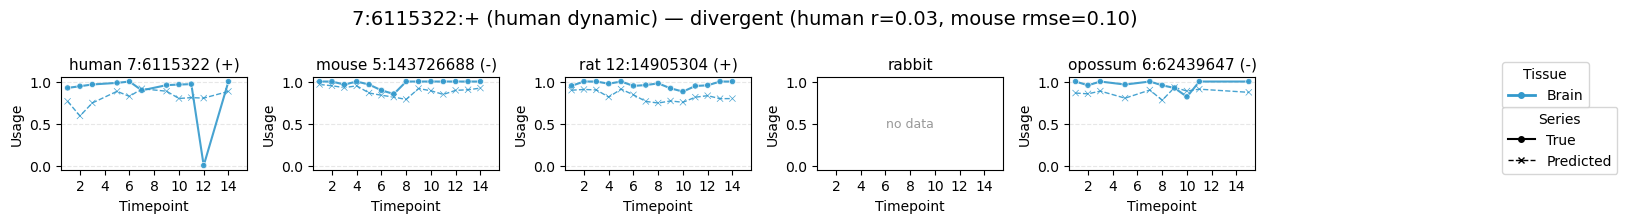

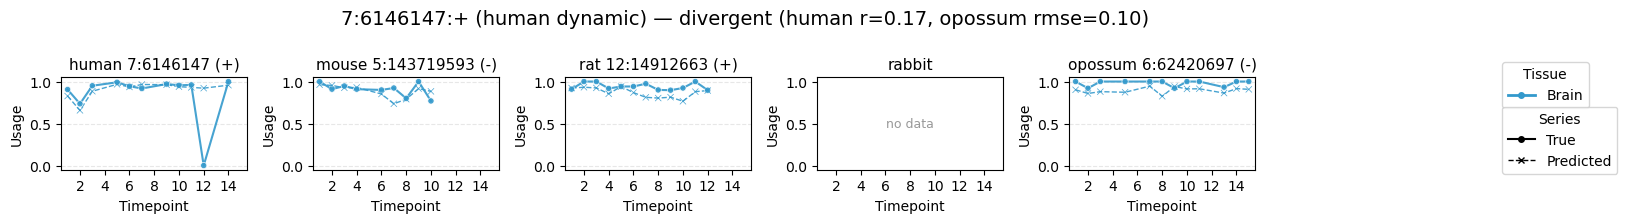

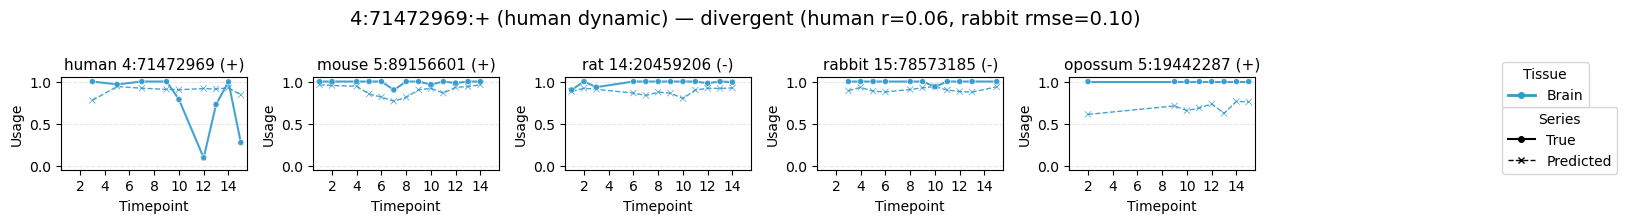

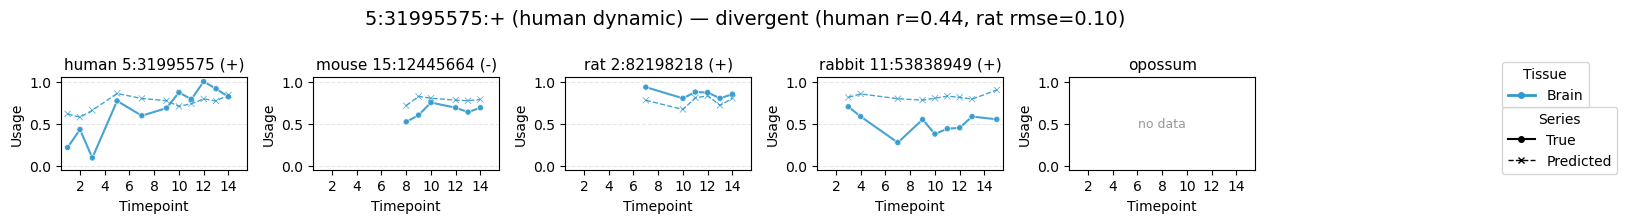

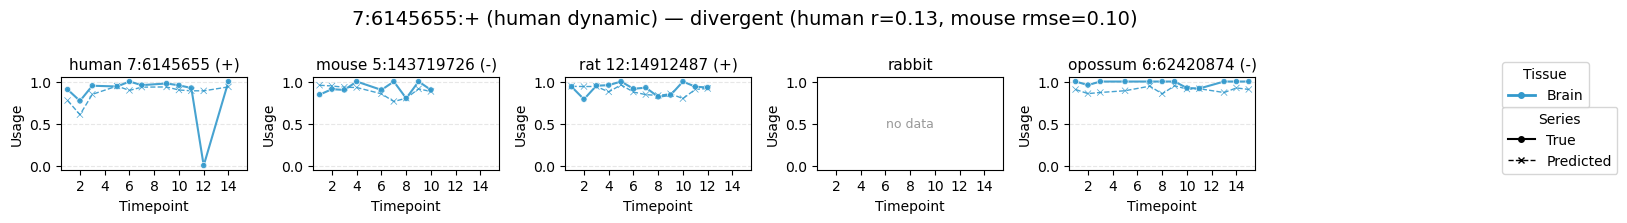

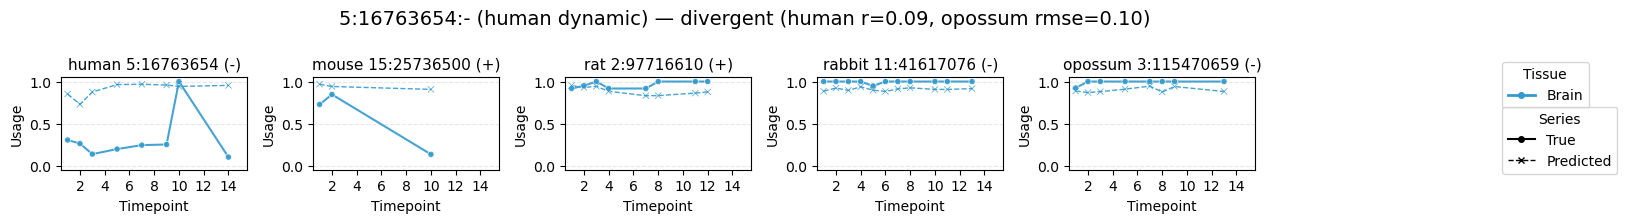

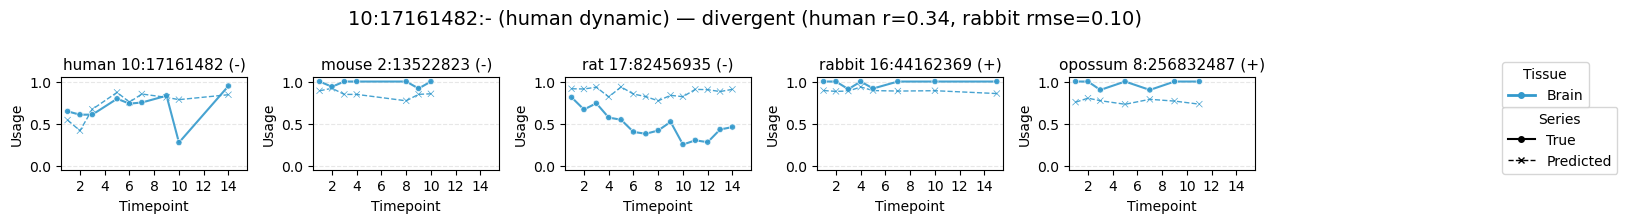

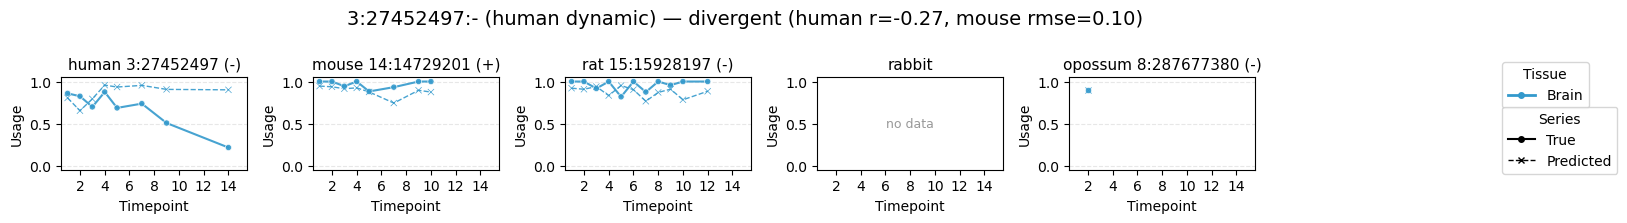

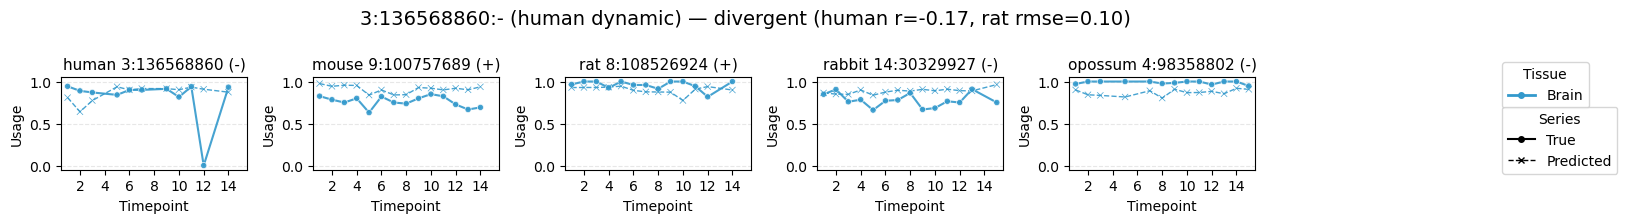

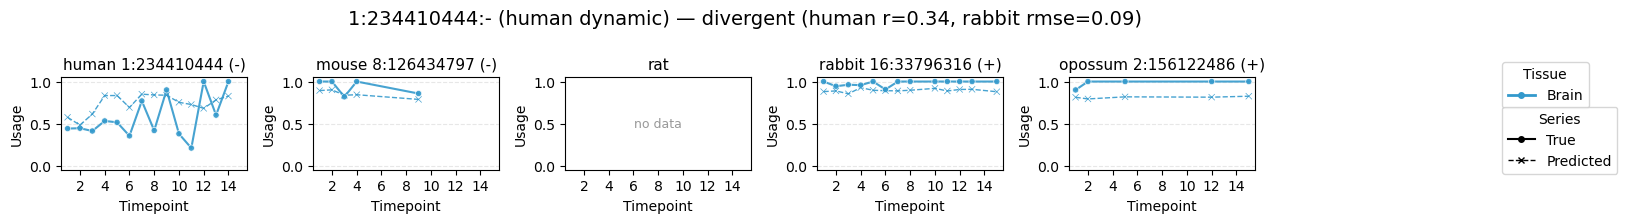

In [67]:
# divergent, but NOT well predicted (poor human r and/or poor other-species RMSE)
mis = comp[(comp["divergent"]) & (comp['human_role'] == "dynamic") &
           ((comp["human_pred_r"] < R_WELL_PRED) | (comp["other_pred_r"] < R_WELL_PRED))]

mis = mis.dropna(subset=["human_pred_r", "other_pred_rmse"])
mis = mis.sort_values("other_pred_rmse", ascending=False)   # worst-predicted first
print(f"{mis['human_site'].nunique():,} human sites divergent & mispredicted in an aligned species")

top_mis = mis.drop_duplicates("human_site").head(N_PLOT)
for _, r in top_mis.iterrows():
    hsite = r["human_site"]
    hchrom = sx.parse_site(hsite)[0]
    frames, coords = [], []
    hf = _load_all_tissues("human", [sx.parse_site(hsite)[1]])
    if hf is not None: frames.append(hf)
    coords.append(f"human {hsite}")                     # human column always present
    for sp in OTHER_SPECIES:                            # one fixed column per species
        rec = records[hsite].get(sp)
        added = False
        if rec:
            ap = sx.parse_site(rec["aln_site"])[1]
            f = _load_all_tissues(sp, [ap])
            if f is not None and not f.empty:
                frames.append(f); coords.append(f"{sp} {rec['aln_site']}"); added = True
        if not added:
            coords.append(f"{sp} {hchrom}:0")           # placeholder -> empty panel
    fig = plot_splice_site_predictions(
        pd.concat(frames, ignore_index=True), site_coords=coords,
        true_col="SSE_true", pred_col="SSE_pred",
        tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER,
        tissue_subset=[FOCUS_TISSUE], n_cols=len(coords), split_by_tissue=False, show_missing=True,
        title=f"{hsite} (human {r['human_role']}) — divergent "
              f"(human r={r['human_pred_r']:.2f}, {r['species']} rmse={r['other_pred_rmse']:.2f})",
    )
    if fig is not None:
        for ax in fig.axes: ax.set_ylim(-0.05, 1.05)
        fig.savefig(os.path.join(OUT_DIR, f"mispred_{hsite.replace(':', '_')}.png"),
                    dpi=200, bbox_inches="tight")
        plt.show()


## 6 — Inspect one human site across all aligned species

For a chosen human site, plot the true (solid) and predicted (dashed) `FOCUS_TISSUE` trajectory
for the human site and its aligned counterpart in every other species. A species panel is left
**empty with the reason** when:
- **no alignment** — the MAF has no aligned base for that species at this human site;
- **aligned, no splice site** — there is an aligned base but no predicted/observed splice site
  within `ALIGN_TOL` bp of it;
- **no predictions** — the species has no prediction file.

In [ ]:
from alphagenome_pytorch.plotting.splicing import plot_splice_site_predictions

def _nearest_pos(sorted_pos, pos, tol):
    if len(sorted_pos) == 0: return None
    j = bisect.bisect_left(sorted_pos, pos)
    cand = [sorted_pos[k] for k in (j - 1, j) if 0 <= k < len(sorted_pos)]
    if not cand: return None
    best = min(cand, key=lambda x: abs(x - pos))
    return int(best) if abs(best - pos) <= tol else None

def _species_site(sp, hsite, tol=ALIGN_TOL, tissue=FOCUS_TISSUE):
    """Resolve the site to plot for `sp`: (status, chrom, pos).
    status in {'ok','no_alignment','no_splice_site','no_predictions'}."""
    row = lift_df[(lift_df["species"] == sp) & (lift_df["human_site"] == hsite)]
    if row.empty:
        return "no_alignment", None, None
    chrom, apos = str(row.iloc[0]["aln_chrom"]), int(row.iloc[0]["aln_pos"])
    win = list(range(apos - tol, apos + tol + 1))
    pr = load_predictions(sp, tissue, positions=win)
    if pr is None:
        return "no_predictions", chrom, apos
    pr = pr[pr["Chromosome"] == chrom]
    if pr.empty:
        return "no_splice_site", chrom, apos
    snapped = _nearest_pos(np.sort(pr["Position"].astype(int).unique()), apos, tol)
    if snapped is None:
        return "no_splice_site", chrom, apos
    return "ok", chrom, snapped

def _load_all_tissues(sp, chrom, pos):
    """All-tissue predictions at one site, laid out for plot_splice_site_predictions."""
    ppath = _pred_path(sp)
    if not os.path.exists(ppath):
        return None
    try:
        df = pd.read_parquet(ppath, filters=[("Position", "==", int(pos))])
    except Exception:
        df = pd.read_parquet(ppath); df = df[df["Position"] == int(pos)]
    df = df[df["Chromosome"].astype(str) == str(chrom)].rename(
        columns={"true": "SSE_true", "pred": "SSE_pred"})
    if "Species" not in df.columns:
        df["Species"] = sp
    df["Chromosome"] = df["Chromosome"].astype(str)
    return df if not df.empty else None

def inspect_aligned_site(site, tol=ALIGN_TOL, tissue=FOCUS_TISSUE):
    """Plot true/pred FOCUS_TISSUE trajectories (via plot_splice_site_predictions) for the
    human site + every species with an aligned splice site; report the reason for the rest."""
    parts = str(site).split(":")
    chrom, pos = (CHROMS[0], int(parts[0])) if len(parts) == 1 else (parts[0], int(parts[1]))
    hsite = sx.ensure_site_strand(f"{chrom}:{pos}", sx.strand_series(USAGE_TMPL, "human"))
    REASON = {"no_alignment": "no alignment",
              "no_splice_site": f"aligned but no predicted splice site within +/-{tol} bp",
              "no_predictions": "no predictions for species",
              "no_data": "no usage/prediction rows at site"}

    frames, coords, reasons = [], [], {}
    for sp in ["human"] + OTHER_SPECIES:
        if sp == "human":
            status, c, ppos = "ok", chrom, pos
        else:
            status, c, ppos = _species_site(sp, hsite, tol, tissue)
        if status != "ok":
            reasons[sp] = REASON[status]; continue
        df = _load_all_tissues(sp, c, ppos)
        if df is None:
            reasons[sp] = REASON["no_data"]; continue
        frames.append(df)
        aln = f"  (Δ{abs(ppos - int(lift_df[(lift_df.species==sp)&(lift_df.human_site==hsite)].iloc[0].aln_pos))}bp)" if sp != "human" else ""
        coords.append(f"{sp} {c}:{ppos}")

    print(f"human {hsite}  |  {tissue}")
    for sp in ["human"] + OTHER_SPECIES:
        print(f"  {sp:8s}: {'plotted' if sp not in reasons else reasons[sp]}")

    if not frames:
        print("Nothing to plot."); return None
    fig = plot_splice_site_predictions(
        pd.concat(frames, ignore_index=True), site_coords=coords,
        true_col="SSE_true", pred_col="SSE_pred",
        tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER, tissue_subset=[tissue],
        n_cols=len(coords), split_by_tissue=False,
        title=f"human {hsite}"
    )
    if fig is not None:
        for ax in fig.axes: ax.set_ylim(-0.05, 1.05)
        fig.savefig(os.path.join(OUT_DIR,
                    f"aligned_site_{hsite.replace(':', '_')}_{tissue.lower()}.png"),
                    dpi=200, bbox_inches="tight")
        plt.show()
    return fig

human 8:130160784  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : aligned but no predicted splice site within +/-10 bp
  rabbit  : aligned but no predicted splice site within +/-10 bp
  opossum : aligned but no predicted splice site within +/-10 bp


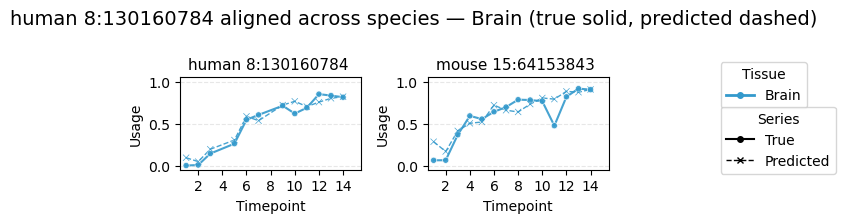

In [32]:
SITE = "8:130160784"
_ = inspect_aligned_site(SITE, tol=10)

human 3:170907641  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


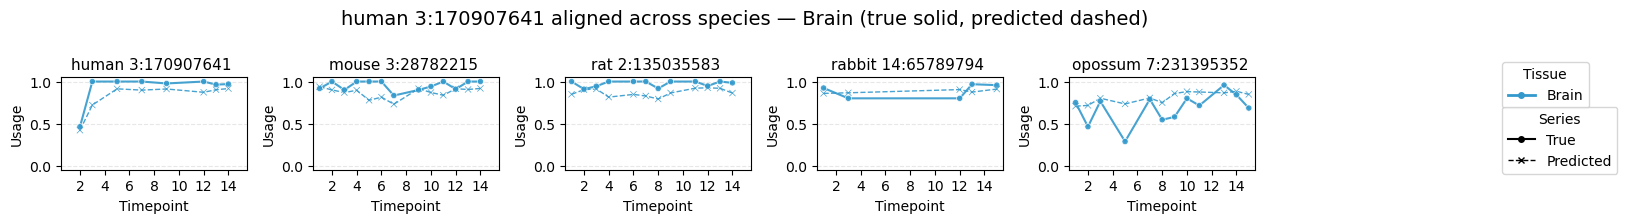

In [33]:
SITE = "3:170907641"
_ = inspect_aligned_site(SITE)

human 1:174800499:+  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : aligned but no predicted splice site within +/-3 bp


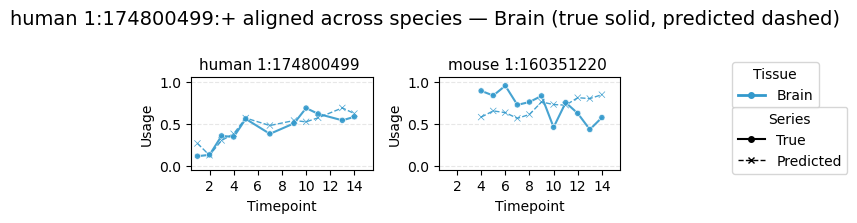

In [70]:
SITE = "1:174800499"
_ = inspect_aligned_site(SITE)

human 1:232404177:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


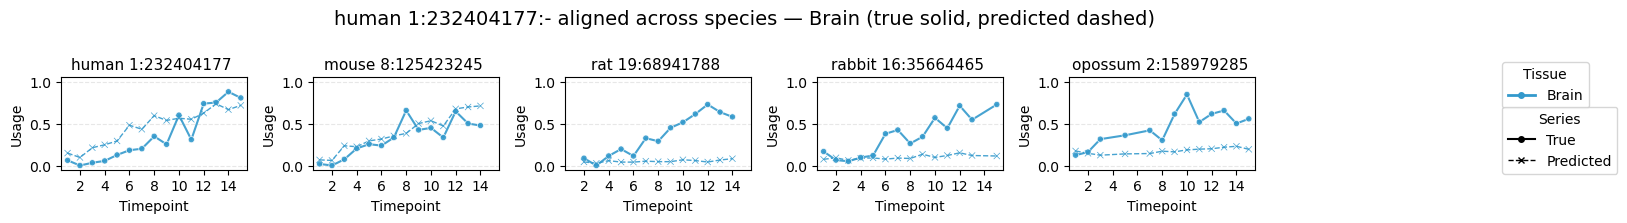

In [71]:
SITE = "1:232404177"
_ = inspect_aligned_site(SITE)

human 9:14120439:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


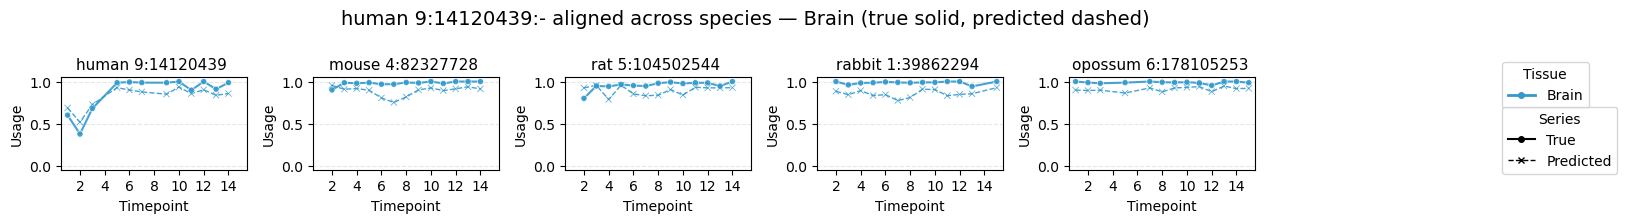

In [73]:
SITE = "9:14120439"
_ = inspect_aligned_site(SITE)

human 10:21173764:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : aligned but no predicted splice site within +/-3 bp


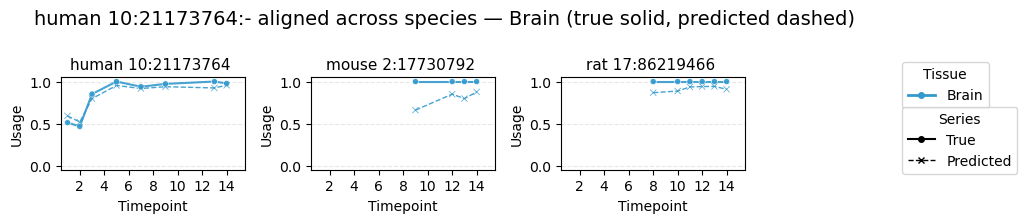

In [74]:
SITE = "10:21173764"
_ = inspect_aligned_site(SITE)

human 10:73396043:-  |  Brain
  human   : plotted
  mouse   : aligned but no predicted splice site within +/-3 bp
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : plotted
  opossum : aligned but no predicted splice site within +/-3 bp


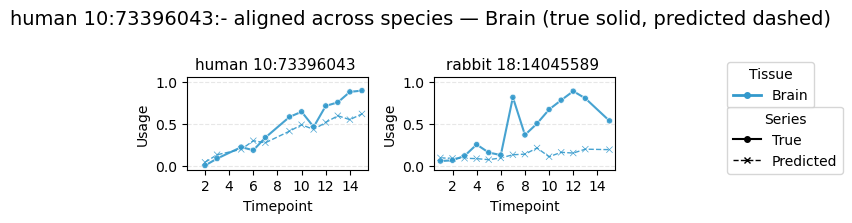

In [72]:
SITE = "10:73396043"
_ = inspect_aligned_site(SITE)

## 7 — Inspect all trajectories for a gene across all aligned species

Specify a **gene** (Ensembl `gene_id` or `gene_name`); the gene span is looked up in the human
GTF-derived gene model, every predicted splice site within that span is collected, and for each
site the aligned splice sites in the other species are resolved and plotted with
`plot_splice_site_predictions` (human + aligned species, `FOCUS_TISSUE`, true solid / predicted
dashed). One figure per splice site (via §6's `inspect_aligned_site`).

In [36]:
# Human GTF-derived gene model (Chromosome / Feature / Start / End / Strand / gene_id / gene_name)
HUMAN_GENE_MODEL = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/Homo_sapiens.parquet"

_gene_tbl_cache = {}
def _human_gene_table():
    if "df" not in _gene_tbl_cache:
        g = pd.read_parquet(HUMAN_GENE_MODEL,
                            columns=["Chromosome", "Feature", "Start", "End", "Strand",
                                     "gene_id", "gene_name"])
        _gene_tbl_cache["df"] = g[g["Feature"] == "gene"].copy()
    return _gene_tbl_cache["df"]

def gene_span(gene):
    """Resolve an Ensembl gene_id or gene_name -> (chrom, start, end, strand, gene_id, gene_name)."""
    g = _human_gene_table()
    hit = g[g["gene_id"] == gene]
    if hit.empty:
        hit = g[g["gene_name"].astype(str).str.lower() == str(gene).lower()]
    if hit.empty:
        raise ValueError(f"gene {gene!r} not found in {HUMAN_GENE_MODEL}")
    r = hit.iloc[0]
    return (str(r["Chromosome"]), int(r["Start"]), int(r["End"]),
            r["Strand"], r["gene_id"], r["gene_name"])

def gene_splice_sites(chrom, start, end):
    """Human predicted splice-site positions within [start, end] on `chrom`."""
    ppath = _pred_path("human")
    try:
        s = pd.read_parquet(ppath, columns=["Chromosome", "Position"],
                            filters=[("Chromosome", "==", str(chrom)),
                                     ("Position", ">=", int(start)), ("Position", "<=", int(end))])
    except Exception:
        s = pd.read_parquet(ppath, columns=["Chromosome", "Position"])
        s = s[(s["Chromosome"].astype(str) == str(chrom)) &
              (s["Position"] >= start) & (s["Position"] <= end)]
    return sorted(s["Position"].astype(int).unique().tolist())

def inspect_gene(gene, tissue=FOCUS_TISSUE, tol=ALIGN_TOL):
    """Find a gene's predicted splice sites and plot each one's true/pred trajectories in
    human + every aligned species (reusing §6's `inspect_aligned_site`)."""
    chrom, start, end, strand, gid, gname = gene_span(gene)
    sites = gene_splice_sites(chrom, start, end)
    print(f"{gname} ({gid})  chr{chrom}:{start:,}-{end:,} ({strand})  "
          f"— {len(sites):,} predicted splice site(s), {tissue}")
    if chrom not in CHROMS:
        print(f"  NOTE: chr{chrom} not in CHROMS={CHROMS}; run §1-§3 with this chromosome "
              f"included so its alignments/lift-over are available.")
    figs = []
    for pos in sites:
        print("-" * 72)
        fig = inspect_aligned_site(f"{chrom}:{pos}", tol=tol, tissue=tissue)
        if fig is not None:
            figs.append(fig)
    print("=" * 72)
    print(f"Plotted {len(figs)} / {len(sites)} sites (rest had no data / no aligned splice site).")
    return figs


In [37]:
GENE = "AMPD2"      # Ensembl gene_id (ENSG...) or gene_name
_ = inspect_gene(GENE)

AMPD2 (ENSG00000116337)  chr1:109,616,103-109,632,055 (+)  — 0 predicted splice site(s), Brain
Plotted 0 / 0 sites (rest had no data / no aligned splice site).


In [38]:
pq = pd.read_parquet("/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/splice_sites_intersect_usage_protein_coding.parquet")
pq[(pq['Chromosome'] == "1" ) & (pq['Position'] > 109625000) & (pq['Position'] < 109625500)]

,Chromosome,Position,SiteType
34853,1,109625302,Acceptor+
34854,1,109625432,Donor+
